### **Machine Learning - Assignment**

#### **Autores**
*Camila de Santana Machado (202108291)*

*Isabel Baptista de Oliveira (202006854)*

*Raquel Faria de Castro (201605159)*

#### **_1st Leg_ - How different ML methods behave on a dataset**

In [1]:
# Libraries import

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

##### Creation of the artificial datasets

In [2]:
# =========================== Gaussian blobs (Headlines) ===========================

def make_headlines(n, balance): # balance = 'balanced' ou 'unbalanced'
    if balance == 'unbalanced':
        nblue = int(n*0.9)
        nred = n-nblue
    else:
        nblue = int(n/2)
        nred = n-nblue
    mean1, mean2 = [0, 0], [2, 2]
    cov = [[1, 0], [0, 1]]

    X1 = np.random.multivariate_normal(mean1, cov, nblue)
    X2 = np.random.multivariate_normal(mean2, cov, nred)

    X = np.vstack([X1, X2])
    y = np.array([0]*(nblue) + [1]*(nred))
    return X, y

# =========================== Shell ===========================

def make_shell (n, balance): # balance = 'balanced' ou 'unbalanced'
    if balance == 'unbalanced':
        nblue = int(n*0.9)
        nred = n-nblue
    else:
        nblue = int(n/2)
        nred = n-nblue

    A= np.random.multivariate_normal([-2,0], [[3,-1],[-1,3]], nblue)
    Bx=np.random.uniform(-10,10, nred)
    By=np.random.uniform(4, 6, nred)
    B=np.column_stack([Bx,By])
    X = np.vstack([A, B])
    y = np.array([0]*nblue + [1]*nred)
    return X,y

# =========================== DD ===========================

def make_dd(n, balance): # balance = 'balanced' ou 'unbalanced'
    if balance =='unbalanced':
        nblue=int(n*0.9)
        nred= n-nblue
    else:
        nblue=int(n/2)
        nred=n-nblue
    
    angles_A = np.random.uniform(-np.pi/2, np.pi/2, nblue)
    radius_A = np.random.uniform(0, 2, nblue)  # uniform fills the whole half-disc
    A_x = radius_A * np.cos(angles_A) - 1.5
    A_y = radius_A * np.sin(angles_A)

    # Class B — right half-disc (filled D facing left)
    angles_B = np.random.uniform(-np.pi/2, np.pi/2, nred)
    radius_B = np.random.uniform(0, 2, nred)
    B_x = radius_B * np.cos(angles_B) + 0.3
    B_y = radius_B * np.sin(angles_B)

    X = np.vstack([
        np.column_stack([A_x, A_y]),
        np.column_stack([B_x, B_y])
    ])
    y = np.array([0]*nblue + [1]*nred)

    return X,y

# =========================== XOR (non linear) ===========================

def make_xor(n, balance): # balance = 'balanced' ou 'unbalanced'
    if balance =='unbalanced':
        nblue=int(n*0.9)
        nred= n-nblue
    else:
        nblue=int(n/2)
        nred=n-nblue
        
    X = np.random.rand(n, 2) * 2 - 1
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    return X, y

# =========================== Chess4 ===========================

def make_chess4(n, balance): # balance = 'balanced' ou 'unbalanced'
    if balance == 'unbalanced':
        nblue = int(n*0.9)
        nred = n-nblue
    else:
        nblue = int(n/2)
        nred = n - nblue

    def chess_points(n, label_parity):
        pts = []
        while len(pts) < n:
            xi = np.random.randint(0, 4)
            yi = np.random.randint(0, 4)
            if (xi + yi) % 2 == label_parity:
                x = xi + np.random.uniform(0, 1)
                y = yi + np.random.uniform(0, 1)
                pts.append([x - 2, y - 2])
        return np.array(pts)

    X1 = chess_points(nblue, 0)
    X2 = chess_points(nred, 1)
    X = np.vstack([X1, X2])
    y = np.array([0]*nblue + [1]*nred)
    return X, y

# =========================== Roseta2 ===========================

def make_roseta2(n, balance): # balance = 'balanced' ou 'unbalanced'
    if balance == 'unbalanced':
        nblue = int(n*0.9)
        nred= n-nblue
    else:
        nblue = int(n/2)
        nred = n - nblue

    angles1 = np.random.uniform(0, 2*np.pi, nblue)
    radii1  = np.random.uniform(0, 1.0, nblue)
    X1 = np.column_stack([radii1*np.cos(angles1), radii1*np.sin(angles1)])

    angles2 = np.random.uniform(0, 2*np.pi, nred)
    radii2  = np.random.uniform(1.5, 2.3, nred)
    X2 = np.column_stack([radii2*np.cos(angles2), radii2*np.sin(angles2)])

    X = np.vstack([X1, X2])
    y = np.array([0]*nblue + [1]*nred)
    return X, y

# =========================== Roseta3 ===========================

def make_roseta3 (n, balance): # balance = 'balanced' ou 'unbalanced'
    if balance == 'unbalanced':
        nblue = int(n*0.9)
        nred = n-nblue
    else:
        nblue = int(n/2)
        nred = n-nblue
    
    blobs=[]
    classes = []

    # Central blob (0)
    A= np.random.multivariate_normal([0,0], [[0.5,-0.1],[-0.1,0.5]], nblue)
    blobs.append(A)
    classes+= [0]*nblue
    
    # Intermediate ring (1)
    inring= np.random.uniform(3.5,5.0,nred)
    angle = np.random.uniform(0, 2*np.pi,nred)
    blobs.append(np.column_stack([inring*np.cos(angle), inring*np.sin(angle)]))
    classes+=[1]*nred

    # Outer ring (0)
    outring = np.random.uniform(6.0,7.5,nblue)
    angle = np.random.uniform(0, 2*np.pi, nblue)
    blobs.append(np.column_stack([outring*np.cos(angle), outring*np.sin(angle)]))
    classes += [0]*nblue

    X = np.vstack(blobs)
    y = np.array(classes)
    return X, y


##### Models to be used in the assignment

In [3]:
def get_models():
    return {
        "1-NN": KNeighborsClassifier(n_neighbors=1),
        "5-NN": KNeighborsClassifier(n_neighbors=5),
        "10-NN": KNeighborsClassifier(n_neighbors=10),
        "Logistic Regression": LogisticRegression(),
        "LDA": LinearDiscriminantAnalysis(),
        "QDA": QuadraticDiscriminantAnalysis()
    }

##### Metrics

In [4]:
# Division of the dataset into training and testing and evaluation of the models with different metrics

def evaluate(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    models = get_models()
    results = {}
    metrics = {'accuracy': accuracy_score,
              'precision': lambda y_test, y_pred: precision_score(y_test, y_pred, average='weighted', zero_division=0),
              'recall': lambda y_test, y_pred: recall_score(y_test, y_pred, average='weighted'),
              'f1': lambda y_test, y_pred: f1_score(y_test, y_pred, average='weighted'),
              'roc_auc': lambda y_test, y_pred_proba: roc_auc_score(y_test, y_pred_proba, average='weighted', multi_class='ovr')
              }
    
    scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)
        
        # metrics testing
        results[name] = {}
        for metric in scoring:
            if metric =='roc_auc':
                results[name][metric]= metrics[metric](y_test,y_pred_proba[:,1])
            else:
                results[name][metric]= metrics[metric](y_test,y_pred)
            
    # order best to worst
    results = dict(sorted(results.items(), key=lambda x: x[1]['f1'], reverse=True))
    return results

##### Execution

In [5]:
datasets = {
    "Headlines (balanced)": make_headlines(1000, 'balanced'),
    "Headlines (unbalanced)": make_headlines(1000, 'unbalanced'),
    "Shell (balanced)": make_shell(1000,'balanced'),
    "Shell (unbalanced)": make_shell(1000,'unbalanced'),
    "DD (balanced)": make_dd(1000,'balanced'),
    "DD (unbalanced)": make_dd(1000,'unbalanced'),
    "XOR (balanced)": make_xor(1000, 'balanced'),
    "XOR (unbalanced)": make_xor(1000, 'unbalanced'),
    "Chess4 (balanced)": make_chess4(1000, 'balanced'),
    "Chess4 (unbalanced)": make_chess4(1000, 'unbalanced'),
    "Roseta2 (balanced)": make_roseta2(1000, 'balanced'),
    "Roseta2 (unbalanced)": make_roseta2(1000, 'unbalanced'),
    "Roseta3 (balanced)": make_roseta3(1000,'balanced'),
    "Roseta3 (unbalanced)": make_roseta3(1000,'unbalanced')
}

for name, (X, y) in datasets.items():
    print(f"\n=== Dataset: {name} ===")
    results = evaluate(X, y)
    
    rows = []
    for model_name, scores in results.items():
        row = {"Model": model_name}
        row.update(scores)
        rows.append(row)
    
    df = pd.DataFrame(rows)
    df = df.sort_values("accuracy", ascending=False).reset_index(drop=True)
    df.index += 1
    df.index.name = "Rank"
    
    display(df.round(3))


=== Dataset: Headlines (balanced) ===


,Model,accuracy,precision,recall,f1,roc_auc
Rank,,,,,,
1,5-NN,0.930,0.931,0.930,0.930,0.958
2,Logistic Regression,0.923,0.924,0.923,0.923,0.978
3,LDA,0.923,0.924,0.923,0.923,0.978
4,QDA,0.923,0.924,0.923,0.923,0.978
5,10-NN,0.913,0.914,0.913,0.913,0.969
6,1-NN,0.903,0.904,0.903,0.903,0.903



=== Dataset: Headlines (unbalanced) ===


,Model,accuracy,precision,recall,f1,roc_auc
Rank,,,,,,
1,LDA,0.960,0.959,0.960,0.958,0.974
2,QDA,0.960,0.959,0.960,0.958,0.974
3,Logistic Regression,0.960,0.960,0.960,0.957,0.974
4,5-NN,0.957,0.957,0.957,0.953,0.917
5,10-NN,0.957,0.957,0.957,0.953,0.942
6,1-NN,0.947,0.944,0.947,0.944,0.833



=== Dataset: Shell (balanced) ===


...

,Model,accuracy,precision,recall,f1,roc_auc
Rank,,,,,,
1,1-NN,1.000,1.000,1.000,1.000,1.000
2,QDA,1.000,1.000,1.000,1.000,1.000
3,5-NN,0.993,0.993,0.993,0.993,1.000
4,10-NN,0.990,0.990,0.990,0.990,1.000
5,Logistic Regression,0.883,0.780,0.883,0.829,0.496
6,LDA,0.883,0.780,0.883,0.829,0.497



=== Dataset: Roseta3 (balanced) ===


,Model,accuracy,precision,recall,f1,roc_auc
Rank,,,,,,
1,1-NN,1.000,1.000,1.000,1.000,1.000
2,5-NN,1.000,1.000,1.000,1.000,1.000
3,10-NN,1.000,1.000,1.000,1.000,1.000
4,Logistic Regression,0.687,0.472,0.687,0.559,0.559
5,LDA,0.687,0.472,0.687,0.559,0.559
6,QDA,0.687,0.472,0.687,0.559,0.484



=== Dataset: Roseta3 (unbalanced) ===


,Model,accuracy,precision,recall,f1,roc_auc
Rank,,,,,,
1,1-NN,0.998,0.998,0.998,0.998,0.985
2,5-NN,0.998,0.998,0.998,0.998,1.000
3,10-NN,0.991,0.991,0.991,0.991,1.000
4,Logistic Regression,0.942,0.888,0.942,0.914,0.545
5,LDA,0.942,0.888,0.942,0.914,0.545
6,QDA,0.942,0.888,0.942,0.914,0.467


In [6]:
# Boundary visualization

def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.show()

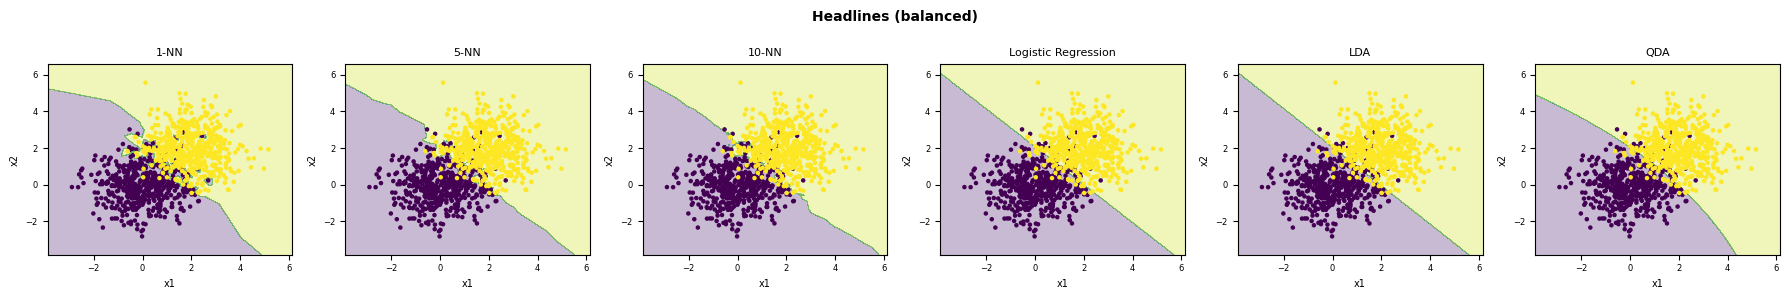

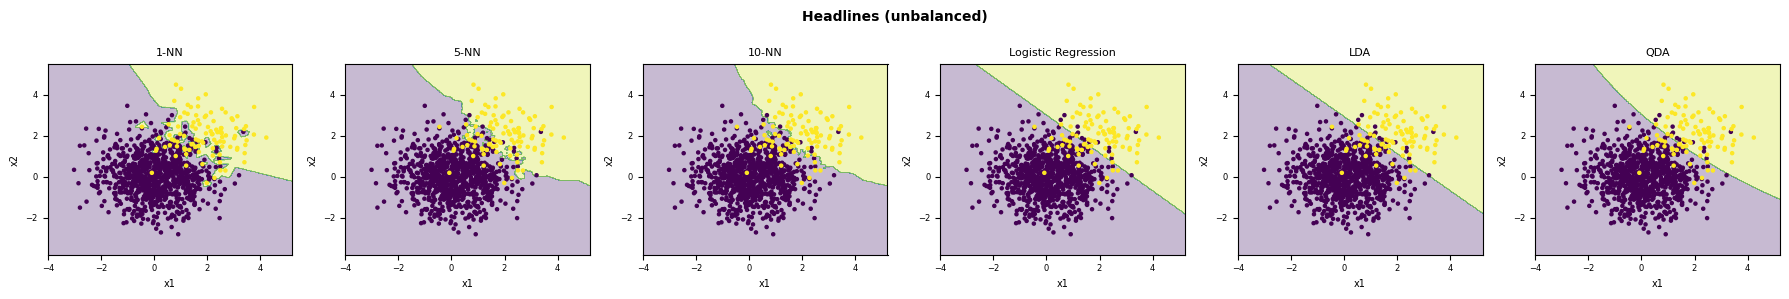

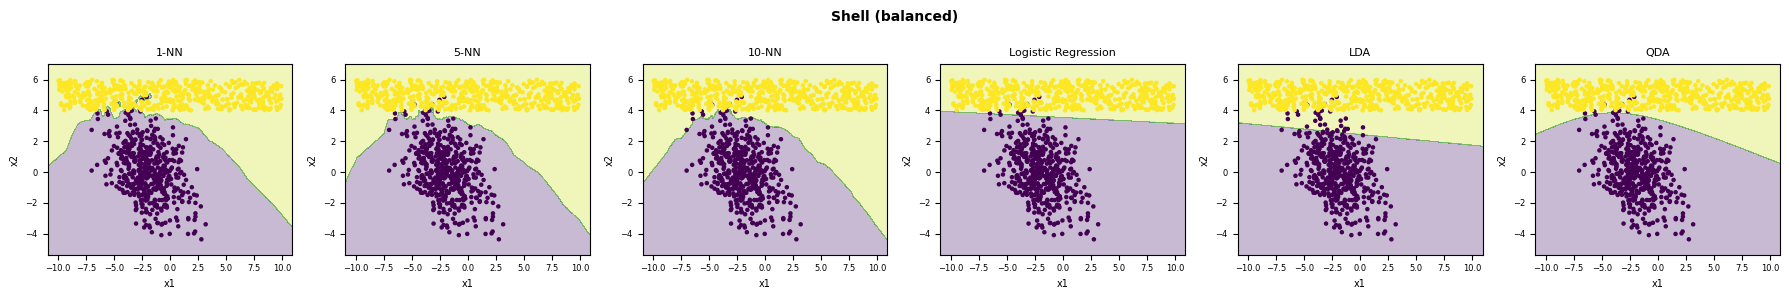

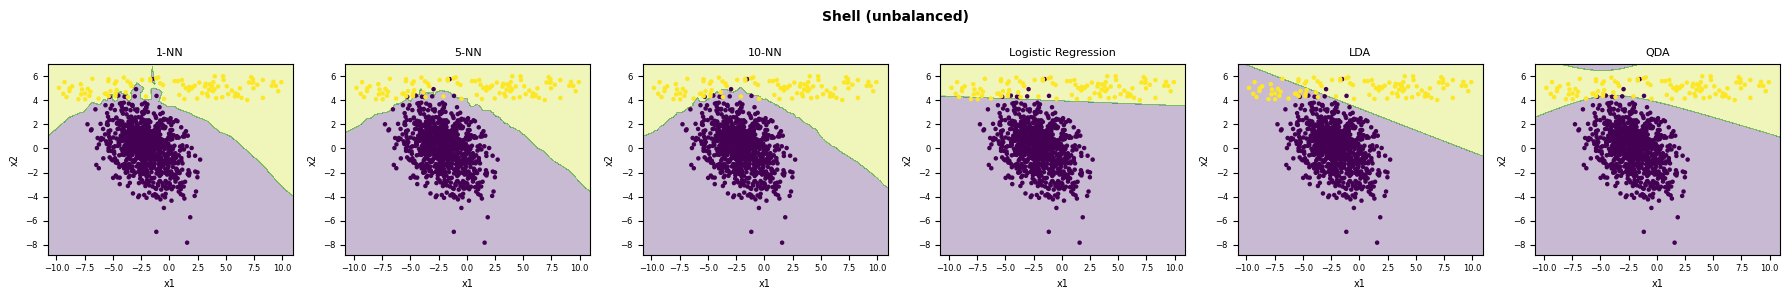

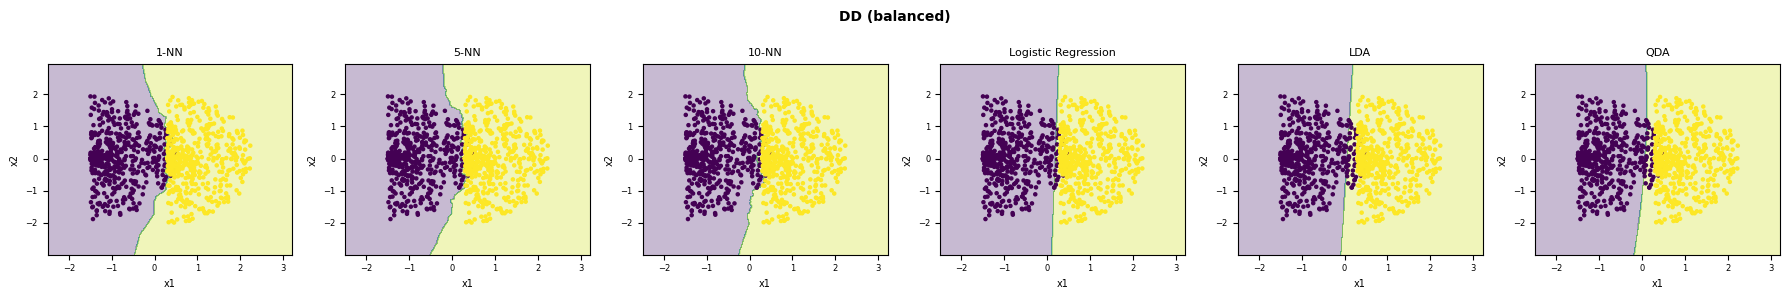

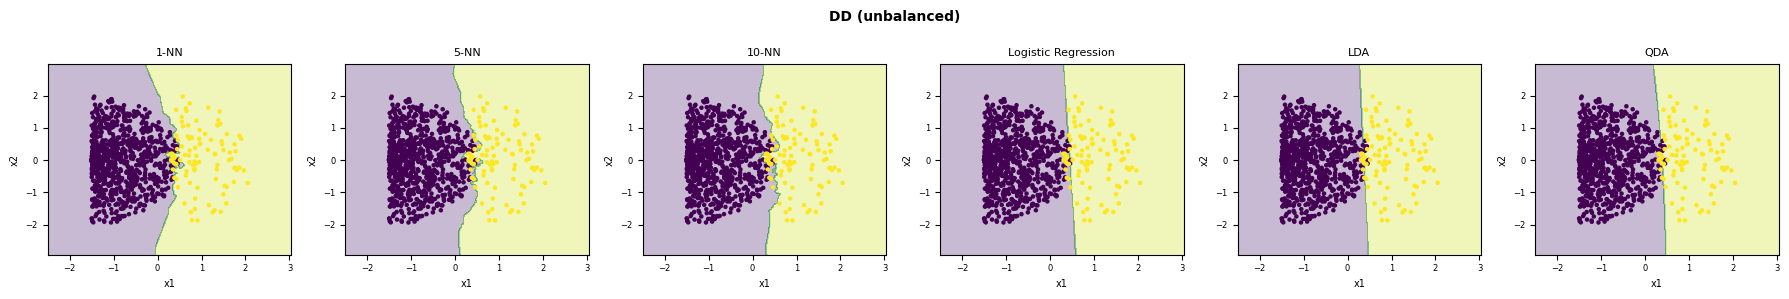

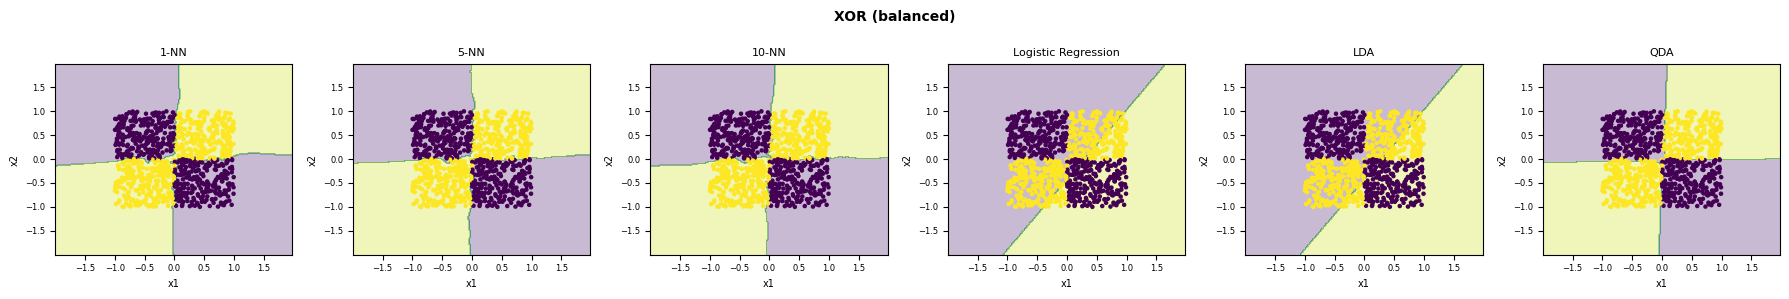

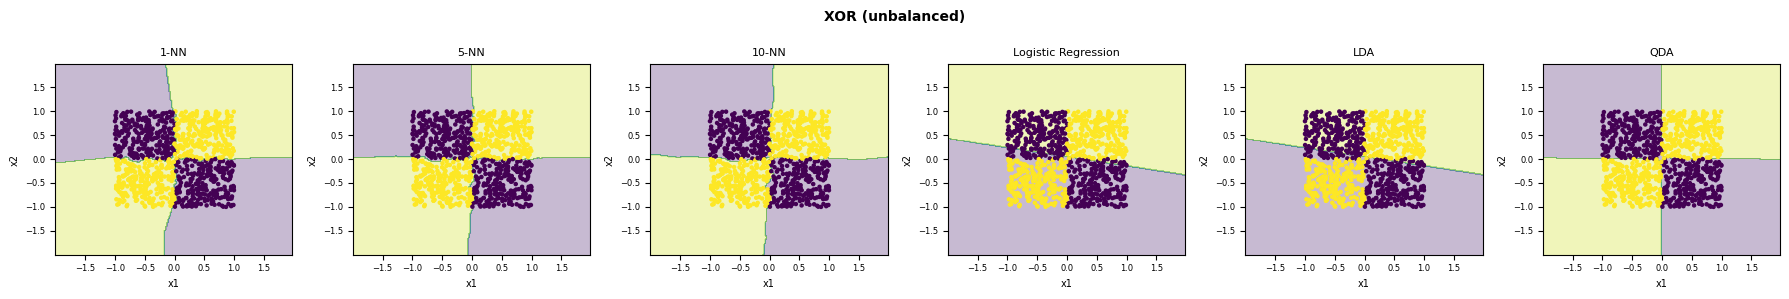

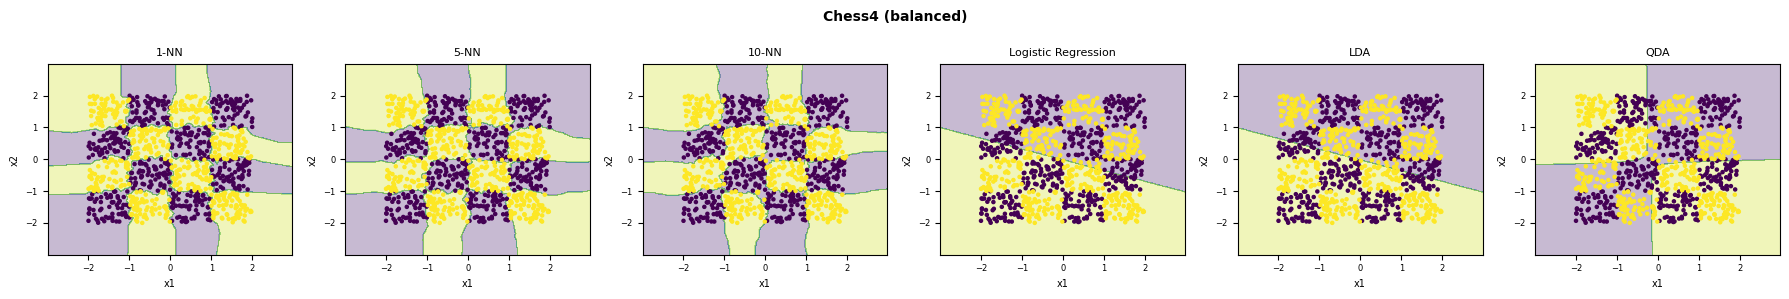

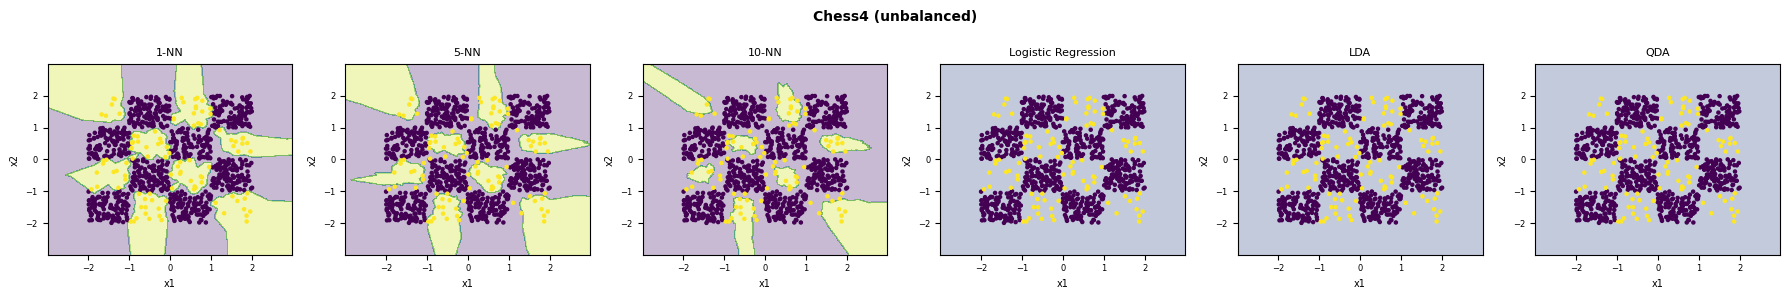

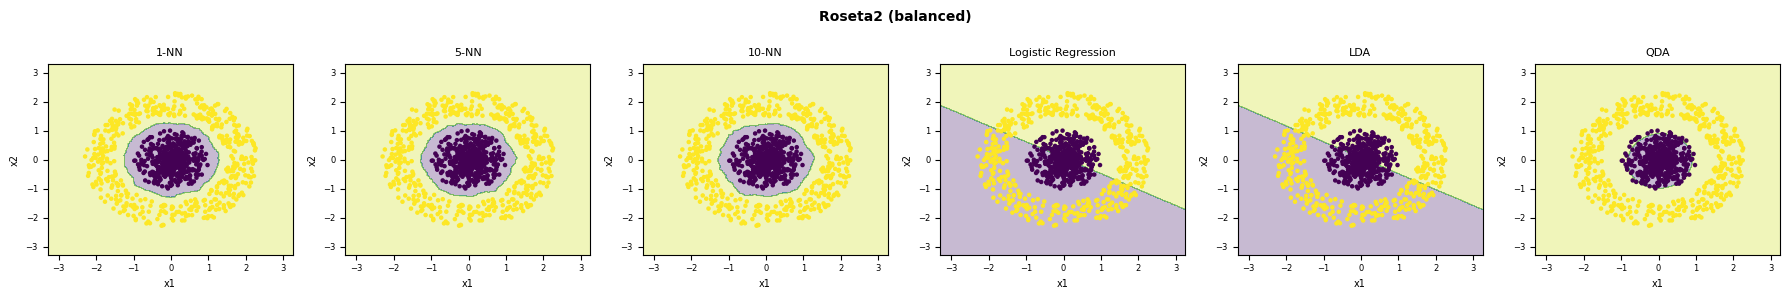

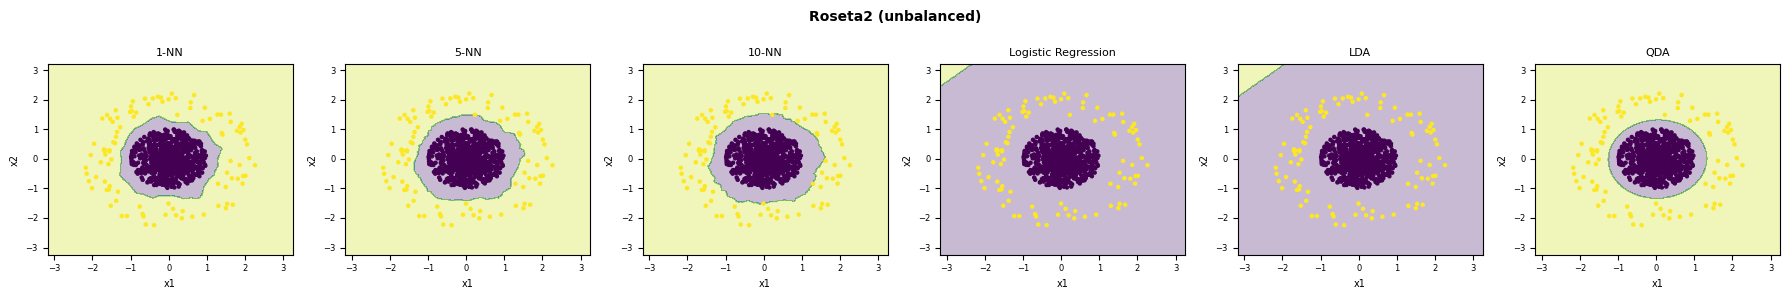

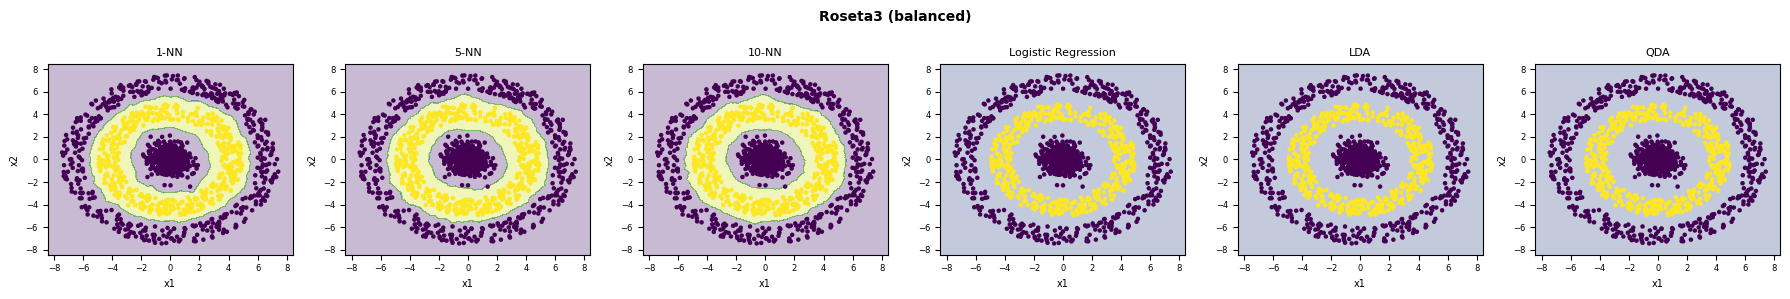

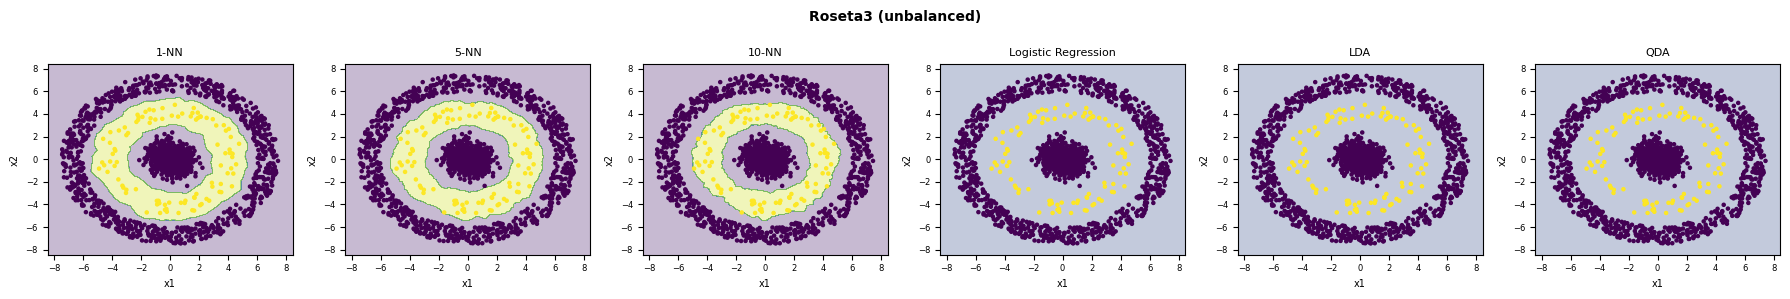

In [7]:
def plot_all_boundaries(dataset_name, X, y, models):
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(3 * n_models, 3))
    
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    for ax, (name, model) in zip(axes, models.items()):
        model.fit(X, y)
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.3)
        ax.scatter(X[:, 0], X[:, 1], c=y, s=5)
        ax.set_title(name, fontsize=8)
        ax.set_xlabel("x1", fontsize=7)
        ax.set_ylabel("x2", fontsize=7)
        ax.tick_params(labelsize=6)

    fig.suptitle(dataset_name, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

for dataset_name, (X, y) in datasets.items():
    plot_all_boundaries(dataset_name, X, y, get_models())

#### Classifier rankings and analysis

_Headlines_

The Headlines dataset consists of two Gaussian blobs with similar covariance. This means that this dataset is good for linear methods. When comparing the different methods' accuracy for both the balanced and unbalanced datasets, the kNN methods (5-NN, 10-NN) and Logistic Regression are consistently well ranked. 1-NN ranks last due to the overfitting to individual points. However, regarding accuracy, all methods have quite similar values, particularly when we look at the balanced dataset. The higher accuracy in the unbalanced dataset but this is misleading, because predicting the majority class more often boosts accuracy. Both LDA and QDA perform similarly, suggesting the two classes share comparable covariance structures. Additionally, Logistic Regression, LDA and QDA obtained a higher ROC-AUC than 10-NN despite the lower accuracy. This suggests that they produce better probability estimates even when their predictions are slightly less accurate.

_Shell_

The Shell dataset consists of a conjugation of 1 circular gaussian blob and one rectangular thin strip of points, creating very different covariance structures for each class. With that said, QDA performs very well because it can model each class with its own covariance. LDA is last in both the balanced and unbalanced dataset due to the different covariances between classes. 

_DD_

The DD dataset pairs two D-shaped half-circular blobs side by side with minimal overlap. Overall there is a very high accuracy across all methods, due to the clean separation between the two classes. In the balanced dataset, 1-NN appears with the highest accuracy value. However, in the unbalanced dataset the 1-NN drops to last as the reduced minority class samples cause wrong classifications near the boundary,  while LDA and QDA rise. This happens because, despite the the curved shape, the small overlap makes even a simple linear boundary (LDA) or quadratic boundary (QDA) sufficient to separate the classes effectively.

_XOR_

The alternating 2x2 square pattern is not linearly separable, causing LDA and Logistic Regression to score really low values. QDA and kNN methods are superior by capturing the non-linear boundary, making XOR the classic example of a non-linearly separable dataset. The ROC-AUC for the linear methods are also really low, confirming they are not just making wrong hard predictions but are also unable to model the class probabilities correctly.

_Chess4_

Due to the fact that Chess4 is an extension of XOR to a 4x4 grid, LDA and Logistic Regression perform, once again, really badly in the balanced case. QDA also fails here, unlike in XOR. These alternating regions require highly local boundaries that even quadratic decision methods cannot capture. Only kNN methods succeed, with 1-NN ranking first due to the sharp, regular nature of the chessboard boundaries.

_Roseta2_

kNN methods achieve perfect accuracy, precision, recall and F1, while LDA and Logistic Regression score really low across all performance metrics. QDA also performs very well, because it can model the circular covariance structure of each class. Regarding linear models, the ring structure is completely invisible to linear methods, as no straight line can separate a blob from a ring around it.

_Roseta3_

Roseta3 is quite similar to Roseta2, only adding a a third concentric ring with alternating classes, pushing complexity further. All kNN methods still achieve perfect or near-perfect accuracy. However, unlike Roseta2, QDA now also fails, joining LDA and Logistic Regression at the bottom. With 3 concentric rings and 2 alternating classes, even quadratic boundaries can't capture the structure, only local methods can do it.

_Main Conclusions_

kNN methods are overall the most robust across datasets because they make no assumptions about data distribution, although 1-NN is more prone to overfitting and sensitive to class imbalance near decision boundaries. LDA assumes linear boundaries and equal class covariances, which limits its effectiveness to datasets such as Headlines. Logistic Regression shares the same linear limitation but is slightly more flexible, leading to somewhat better results in some cases. QDA can model moderately non-linear boundaries, performing well on datasets such as Shell, XOR, and Roseta2, but struggling with more complex datasets like Chess4 and Roseta3. 
The main lesson from thi part of the project is that there is no universally best classifier. Performance depends heavily on how well the model assumptions align with the structure of the data.

#### Proposed Dataset: Two Well-Separated Gaussian Blobs with Equal Covariance

As we have seen in the previous datasets, kNN methods are the most robust across the different studied datasets, because they make no assumptions about the data distribution. To change this predominance of kNN methods, we propose a dataset consisting of two Gaussian blobs with identical covariances, well-separated centers, and no overlap. This is the ideal setting for linear models, particularly LDA.

#### **_2nd Leg_ - Study the bias-variance decomposition of Trees, Ensembles, SVM and MLP**

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score

##### Data loading and exploration 

In [9]:
# Load the breast cancer wisconsin dataset

data= load_breast_cancer()
df = pd.DataFrame(data=data, columns = data.feature_names)

In [10]:
# Check the structure of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   mean radius              0 non-null      object
 1   mean texture             0 non-null      object
 2   mean perimeter           0 non-null      object
 3   mean area                0 non-null      object
 4   mean smoothness          0 non-null      object
 5   mean compactness         0 non-null      object
 6   mean concavity           0 non-null      object
 7   mean concave points      0 non-null      object
 8   mean symmetry            0 non-null      object
 9   mean fractal dimension   0 non-null      object
 10  radius error             0 non-null      object
 11  texture error            0 non-null      object
 12  perimeter error          0 non-null      object
 13  area error               0 non-null      object
 14  smoothness error         0 non-null      object
 15  c

In [11]:
# Check for missing values

print(df.isna().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


#####  Bias-Variance Decomposition via _Bootstrapping_ 

In [12]:
# Creating the variables 
X= data.data
y= data.target 

# Data splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42,
    shuffle=True
)

def bias_variance(model,X_train, y_train, X_test, y_test, B=100):
    # Prediction matrix -> B rows and len(X_test) columns
    prediction = np.zeros((B, len(X_test)))

    # Fill in the matrix
    for i in range (B):
        
        # Create the bootstrap samples
        n = np.random.choice(len(X_train), size = len(X_train), replace=True)
        X_new = X_train[n]
        y_new = y_train[n]

        # Model fitting
        model.fit(X_new, y_new)

        # Storing the predictions
        prediction[i]= model.predict_proba(X_test)[:,1]

    # Most frequent prediction, bias, variance, error
    most_freq_pred = np.mean(prediction, axis=0)
    bias= np.mean((most_freq_pred-y_test)**2)
    variance = np.mean(np.var(prediction, axis=0))
    error = bias + variance

    return bias, variance, error

###### **Generating the different models**

In [13]:
models = {

    # Decision Tree
    'DT': {
        'model': DecisionTreeClassifier(),
        'param_name': 'max_depth',
        'param_value': [1, 5, 10, 50, 200]
    },
    
    # Random Forest
    'RF': {
        'model': RandomForestClassifier(),
        'param_name': 'n_estimators',
        'param_value': [1, 5, 10, 50, 200]
    },

    # Bagging
    'Bagging':{
        'model': BaggingClassifier(),
        'param_name': 'n_estimators',
        'param_value': [1, 5, 10, 50, 200]
    },

    # Gradient Boosting
    'GD': {
        'model': GradientBoostingClassifier(),
        'param_name': 'n_estimators',
        'param_value': [1, 5, 10, 50, 200],
    },

    # SVM
    'SVM_linear': {
        'model':make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True,random_state=42)),
        'param_name': 'svc__C',
        'param_value': [0.001, 0.01, 0.1, 1, 10, 100],
    },

    
    'SVM_rbf': {
        'model':make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True,random_state=42)),
        'param_name': 'svc__C',
        'param_value': [0.001, 0.01, 0.1, 1, 10, 100],
    },

    # Neural Network
    'MLP':{
        'model': make_pipeline(StandardScaler(), MLPClassifier(max_iter=1000)),
        'param_name': 'mlpclassifier__alpha',
        'param_value': [0.0001, 0.001, 0.01, 0.1, 1.0]
    }
}

###### **Results**

In [14]:
results = {}

for name, config in models.items():
    results[name]=[]

    # Iterate over the hyperparametes in the different models and set_params() so that parameter name = parameter value (ex.: n_estimators=5)
    for param_value in config['param_value']:
        model= config['model'].set_params(**{config['param_name']: param_value})

        # Bootstrap
        bias, variance, error = bias_variance(model, X_train, y_train, X_test, y_test, B=100)

        # Append bias_variance output to results dictionary 
        results[name].append({
            'param_name' : config['param_name'],
            'param_value': param_value,
            'bias': bias,
            'variance': variance,
            'error': error
        })

To study the bias-variance tradeoff, we evaluated each model across a range of values for its most relevant complexity parameter: _max_depth_ for Decision Trees, _n_estimators_ for ensemble methods (Random Forest, Bagging, Gradient Boosting), _C_ for SVMs, and _alpha_ (regularization) for MLP.

In [15]:
# Create a dataframe with the results dictionary -> for visualization and plotting reasons
rows = []

for model_name, model_results in results.items():

    for value in model_results:
        
        # Append to rows
        rows.append({
            'Model': model_name,
            'Parameter_name': value['param_name'],
            'Parameter': value['param_value'],
            'Bias': value['bias'],
            'Variance': value['variance'],
            'Error': value['error']
        })

df_results = pd.DataFrame(rows)

df_results.round(4)

,Model,Parameter_name,Parameter,Bias,Variance,Error
0,DT,max_depth,1.0000,0.0546,0.0324,0.0870
1,DT,max_depth,5.0000,0.0405,0.0432,0.0837
2,DT,max_depth,10.0000,0.0380,0.0462,0.0842
3,DT,max_depth,50.0000,0.0362,0.0450,0.0812
4,DT,max_depth,200.0000,0.0393,0.0452,0.0846
5,RF,n_estimators,1.0000,0.0389,0.0562,0.0951
6,RF,n_estimators,5.0000,0.0369,0.0124,0.0493
7,RF,n_estimators,10.0000,0.0368,0.0069,0.0436
8,RF,n_estimators,50.0000,0.0363,0.0029,0.0391
9,RF,n_estimators,200.0000,0.0368,0.0021,0.0389


###### **Bias-Variance against model complexity**

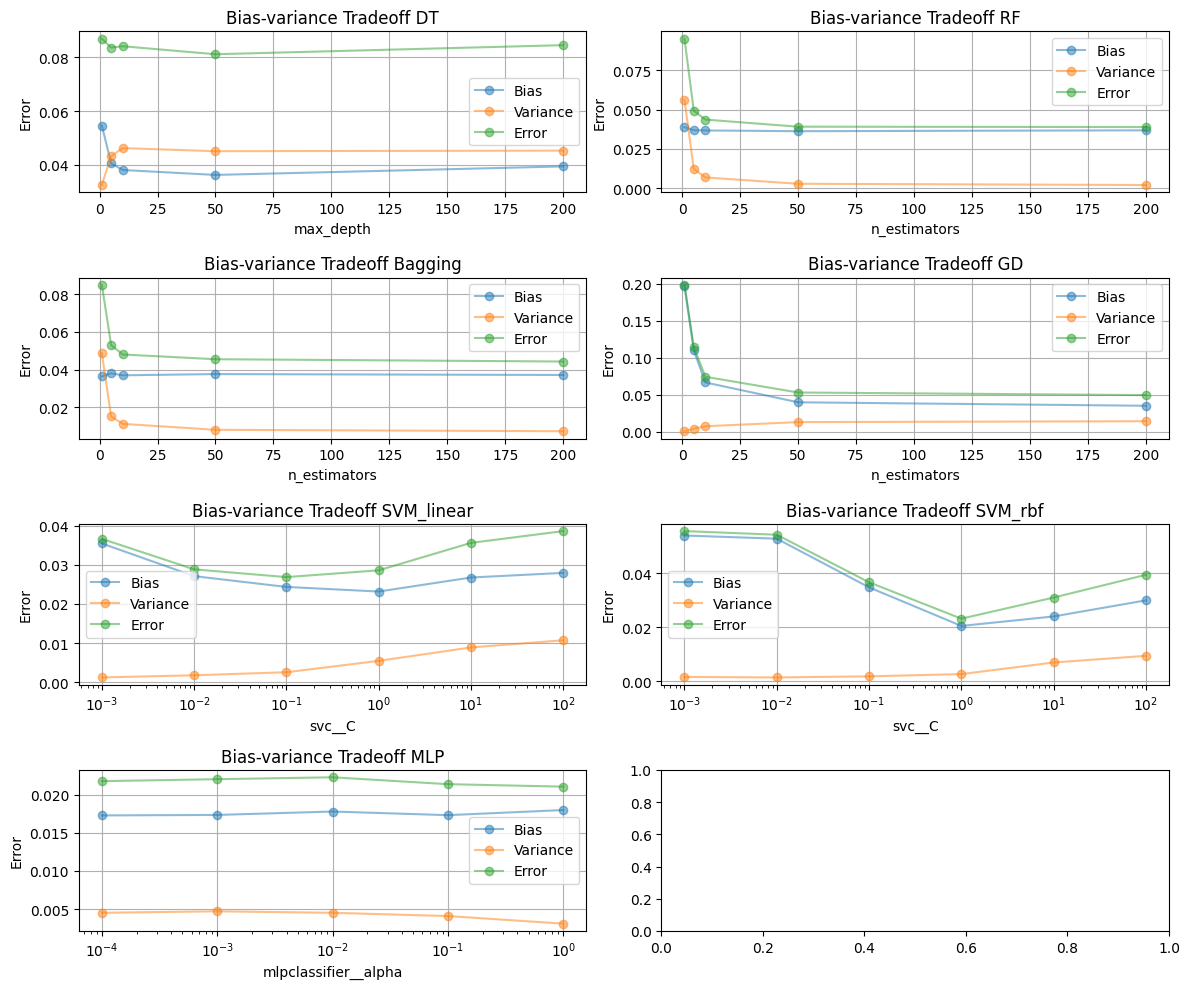

In [16]:
# Get unique models 
models= df_results['Model'].unique()
unique_models=len(models)

# Plotting the data
fig, axes = plt.subplots(4,2, figsize= (12,10))
axes= axes.flatten()

# Iterate over the different model's parameters in df_results, for each, plot bias variance and error against model complexity
for ax, model in zip(axes, models):
    
    df_model=(df_results[df_results['Model']==model].sort_values('Parameter'))
    p_name = df_model['Parameter_name'].iloc[0]
    ax.plot(df_model['Parameter'], df_model['Bias'], marker='o', label='Bias', alpha=0.5)
    ax.plot(df_model['Parameter'], df_model['Variance'], marker='o', label='Variance', alpha=0.5)
    ax.plot(df_model['Parameter'], df_model['Error'], marker='o', label='Error', alpha=0.5)
    ax.set_title('Bias-variance Tradeoff ' f'{model}')
    ax.set_xlabel(f'{p_name}')
    ax.set_ylabel('Error')
    ax.grid(True)
    ax.legend()

# log scale for SVM and MLP
    if model in ['SVM_linear', 'SVM_rbf', 'MLP']:
        ax.set_xscale('log')

plt.tight_layout()
plt.show()

_Decision Tree_

At max_depth=1 the model had a high bias and relatively low variance, underfitting the data. As depth increases, bias dropped but variance rises, with the smallest total error value at max_depth=5. When we look at higher depth values, we see that deeper trees do not reduce bias but keep variance elevated, meaning that unconstrained trees overfit. With this model, we can see the classic bias-variance tradeoff.

_Random Forest_

At n_estimators=1, RF behaved similarly to a single unconstrained tree, presenting a high variance (comparable with the DT at max_depth=200). When we added more trees, variance dropped while bias remained constant. This means that averaging many decorrelated trees reduces variance without introducing bias.

_Bagging_

Bagging is similar to Random Forest's behaviour. Variance decreases when more estimators are added while bias stays stable. However, RF reduced variance faster and reached a lower final variance. This happened because, in RF, each split only considers a random subset of features. Extra randomization in RF means the trees are more decorrelated.

_Gradient Boosting_

At n_estimators=1 bias was very high and variance was near zero, meaning that a single learner underfits. As more estimators were added, bias dropped while variance increased. This reflects boosting: each tree corrected the errors of the previous ones, progressively reducing bias, but this also translated in increasing sensitivity to the training data.

_SVM (Linear)_

Linear SVM showed a bias-variance tradeoff controlled by C. When C was small, meaning the model accepted misclassifications to keep the margin wide, bias was higher and variance was low. As C increased and the model tightned the boundary to correctly classify as many points as possible, bias decreased and variance increased. The optimal total error is achieved in C=0.1, where the tradeoff is best balanced. 

_SVM (RBF)_

The RBF SVM followed a similar pattern to the linear SVM but started with higher bias at a low C value, because the kernel needs sufficient freedom to model the non-linear boundary. The optimal C value is at C=1 with the lowest total error, after which variance grows as the model started to overfit to individual training points. Compared to the linear SVM, RBF obtained a lower error, which could mean that the breast cancer dataset has some non-linear structure that the RBF considers.

_MLP_

MLP was the most stable model. Across all values of alpha, bias, variance and total error remained almost unchanged. This suggests that the parameter alpha alone is not a strong enough to significantly alter the bias-variance tradeoff within this range. The breast cancer dataset is likely simple enough for MLP, and for that reason, regularization does not meaningfully impact performance.The MLP also achieved the lowest total error, among all models studied.

###### **Learning Curves**

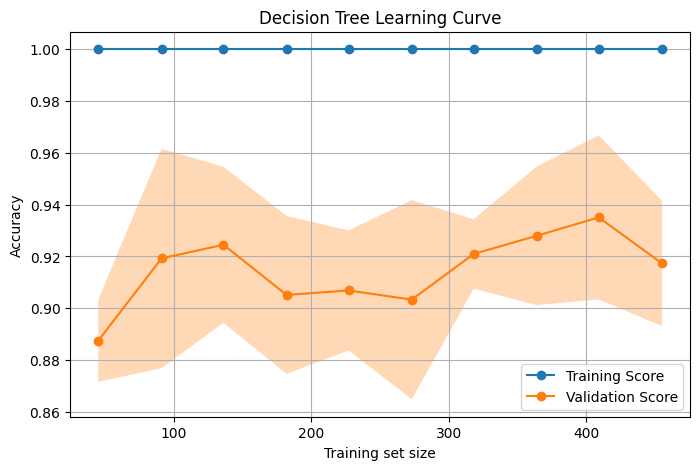

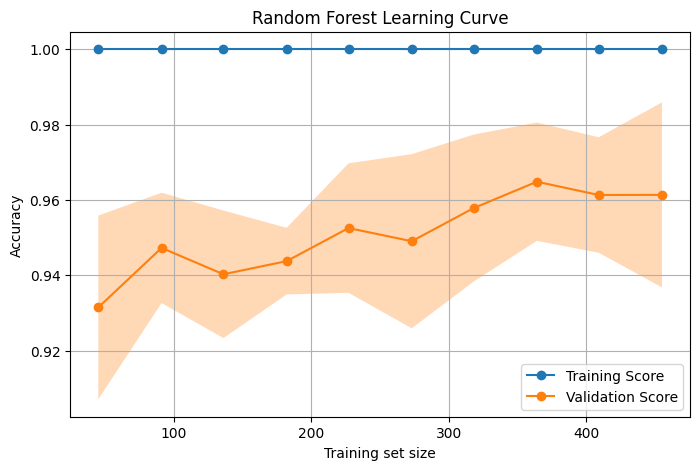

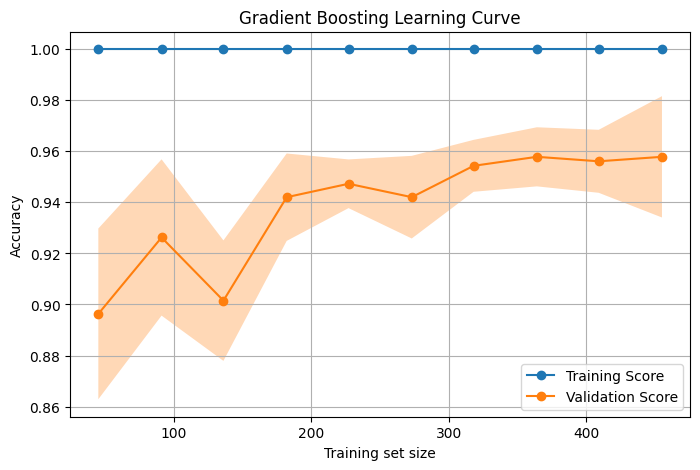

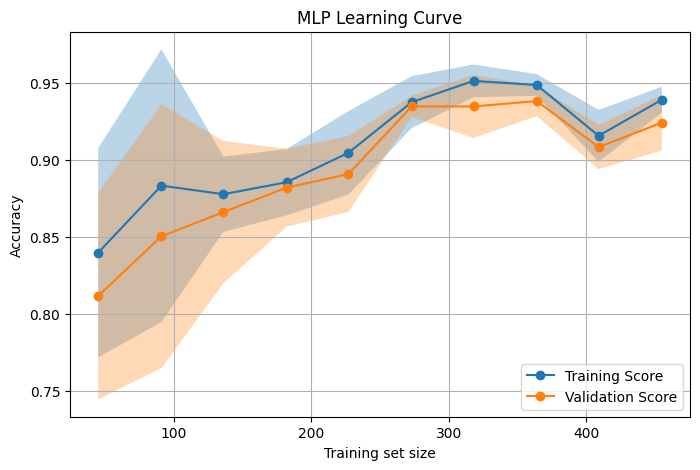

In [17]:
# Consider different learning curves
def plot_lc(model, X,y, title):

    # Create 10 data subsets of different sizes
    train_sizes, train_scores, valid_scores = learning_curve(estimator = model, X=X, y=y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1,1.0,10), shuffle=True, random_state=42)
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    valid_mean= np.mean(valid_scores, axis=1)
    valid_std= np.std(valid_scores, axis=1)

    # Plotting train_mean and valid_mean against different training sizes
    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, marker= 'o',label='Training Score')
    plt.plot(train_sizes, valid_mean, marker='o', label='Validation Score')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.3)
    plt.fill_between(train_sizes, valid_mean-valid_std, valid_mean+valid_std, alpha=0.3)
    plt.title(title)
    plt.xlabel('Training set size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Apply to the different models

# Decision Tree
plot_lc(DecisionTreeClassifier(max_depth=20, random_state=42), X, y,'Decision Tree Learning Curve')

# Random Forest
plot_lc(RandomForestClassifier(n_estimators=100, random_state=42), X, y,'Random Forest Learning Curve')

# Gradient Boosting
plot_lc(GradientBoostingClassifier(n_estimators=100, random_state=42), X, y, 'Gradient Boosting Learning Curve')

# MLP
plot_lc(MLPClassifier(hidden_layer_sizes=(100,), activation='relu', alpha=0.0001, max_iter=2000, random_state=42), X, y, 'MLP Learning Curve')

###### **Learning curves interpretation**

Learning curves plot accuracy against the size of the training set, and are a complementary tool to the bias-variance decomposition. They help distinguish whether a model suffers from high bias or high variance by observing how training and validation scores evolve as the training set size increases. A high bias (underfitting) results in both curves converging at a low value. High variance (overfitting) manifests as a large gap between the training and validation curves, as the model scores well on data it has seen but fails to generalize to new data.

- _Decision Tree_: Training score is fixed at 1.00 regardless of training set size, while validation score stays around 0.91-0.93 with a wide confidence band. The gap and perfect training score confirm high variance, as the tree memorizes the training data completely.

- _Random Forest_: Shows the same pattern of perfect training score and a clear gap to validation score, but the validation score is higher and the confidence band narrows slightly as more data is added, suggesting that ensembling reduces variance compared to a single tree.

- _Gradient Boosting_: Similar to the other ensemble methods, training score stays at 1.00 while validation score improves gradually with more data. The gap remains large, indicating high variance, though the upward trend in validation score suggests it could benefit from more training data.

- _MLP_: Is clearly the most well-behaved model. Both training and validation curves run close together and both improve steadily with more data, reflecting the low and stable bias-variance tradeoff already observed in the decomposition results.

Overall, the learning curves reinforce the findings from the bias-variance decomposition. Tree-based models and ensembles consistently show high variance through their perfect training scores and persistent gaps, while the MLP demonstrates the most balanced behaviour. A common thread across all models is that validation scores improve as training set size grows, suggesting that all models would benefit from more data

###### **Stage Prediction for Gradient Boosting**

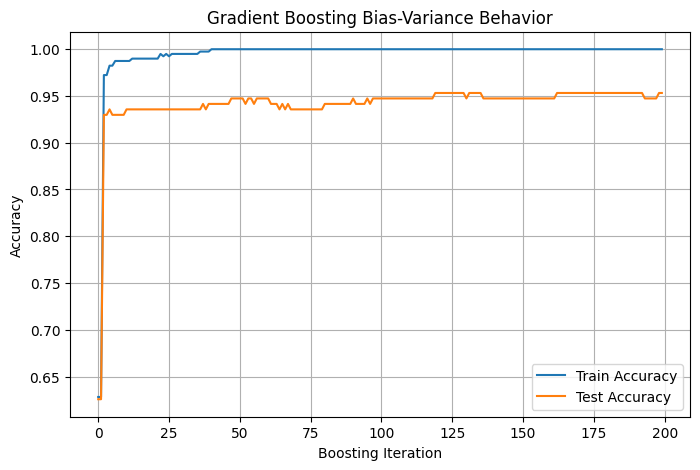

In [18]:
# Tune the model
boost_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Fit to training data
boost_model.fit(X_train, y_train)

# Create the train and test score lists that will store the results
train_scores = []
test_scores = []


for y_pred_train, y_pred_test in zip(
    boost_model.staged_predict(X_train),
    boost_model.staged_predict(X_test)
):

    train_scores.append(
        accuracy_score(y_train, y_pred_train)
    )

    test_scores.append(
        accuracy_score(y_test, y_pred_test)
    )

# Plot the graph of train and test accuracy against boosting progression
plt.figure(figsize=(8,5))
plt.plot(train_scores, label='Train Accuracy')
plt.plot(test_scores, label='Test Accuracy')
plt.xlabel('Boosting Iteration')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting Bias-Variance Behavior')
plt.legend()
plt.grid(True)
plt.show()

The staged prediction plot is used to study train and test accuracy at each boosting iteration, revealing how bias and variance evolve as more trees are added.

_Bias Reduction_: At the first iterations, both train and test accuracy started low, reflecting the high bias of a single learner. As more trees were 
added, both curves rised sharply, because the model rapidly corrected its errors at each stage, which is the main mechanism of boosting. When the model approached the 50 iterations, train accuracy reaches 1.00, confirming that bias has been almost completely eliminated.

_Variance Increase_: While train accuracy stabilized at 1.00 after approximately 50 iterations, test accuracy continued to fluctuate and did not significantly increase beyond that point. The gap between train and test accuracy as boosting iterations increased is the signature of the rising variance.

_Overfitting_: The overfitting is visible around 50 iterations, where test accuracy stays stable at around 0.95 and stopped improving. Beyond this point, adding more trees brought no benefit. This suggests that for this dataset, 200 estimators is excessive and a value around 50 would be sufficient. This is consistent with the bias-variance decomposition results, where total error was already low at 50 estimators.

##### Bias-Variance Decomposition via _Out-of-Bag (OOB)_ for Bagging and Random Forest

In [19]:
# Stored results for both bagging and random forest
results = []

n_estimators_list = [50, 100, 200, 300]

# Bagging
for n in n_estimators_list:

    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n,
        bootstrap=True,
        oob_score=True,
        random_state=42
    )

    bagging_model.fit(X_train, y_train)

    results.append({
        'Model': 'Bagging',
        'n_estimators': n,
        'Train Accuracy': bagging_model.score(X_train, y_train),
        'Test Accuracy': bagging_model.score(X_test, y_test),
        'OOB Accuracy': bagging_model.oob_score_
    })

# Random Forest
for n in n_estimators_list:

    rf_model = RandomForestClassifier(
        n_estimators=n,
        bootstrap=True,
        oob_score=True,
        random_state=42
    )

    rf_model.fit(X_train, y_train)

    results.append({
        'Model': 'Random Forest',
        'n_estimators': n,
        'Train Accuracy': rf_model.score(X_train, y_train),
        'Test Accuracy': rf_model.score(X_test, y_test),
        'OOB Accuracy': rf_model.oob_score_
    })

# Convert Results into a dataframe for visualization and plotting purposes

results_df = pd.DataFrame(results)

print(results_df)

           Model  n_estimators  Train Accuracy  Test Accuracy  OOB Accuracy
0        Bagging            50             1.0       0.941520      0.949749
1        Bagging           100             1.0       0.947368      0.954774
2        Bagging           200             1.0       0.947368      0.952261
3        Bagging           300             1.0       0.947368      0.954774
4  Random Forest            50             1.0       0.923977      0.949749
5  Random Forest           100             1.0       0.935673      0.957286
6  Random Forest           200             1.0       0.941520      0.967337
7  Random Forest           300             1.0       0.941520      0.967337


###### **Plotting OOB - Bagging vs. Random Forest** 

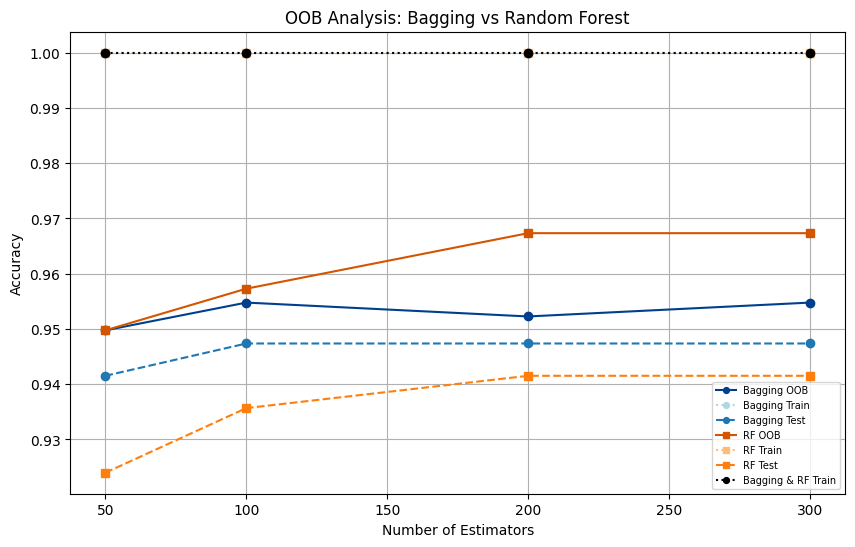

In [27]:
# Creating the plot
plt.figure(figsize=(10,6))

# Bagging
bagging_df = results_df[
    results_df['Model'] == 'Bagging'
]

plt.plot(
    bagging_df['n_estimators'],
    bagging_df['OOB Accuracy'],
    marker='o',
    label='Bagging OOB',
    color='#003f8e'
)

plt.plot(
    bagging_df['n_estimators'], 
    bagging_df['Train Accuracy'],
    marker='o', 
    linestyle=':',
    label='Bagging Train',
    color='#add8e6'
)

plt.plot(
    bagging_df['n_estimators'],
    bagging_df['Test Accuracy'],
    marker='o',
    linestyle='--',
    label='Bagging Test',
    color='#1f77b4'
)

# Random Forest
rf_df = results_df[
    results_df['Model'] == 'Random Forest'
]

plt.plot(
    rf_df['n_estimators'],
    rf_df['OOB Accuracy'],
    marker='s',
    label='RF OOB',
    color='#d45500'
)

plt.plot(
    rf_df['n_estimators'], 
    rf_df['Train Accuracy'],
    marker='s',
    linestyle=':',
    label='RF Train',
    color='#ffbb78' 
)

plt.plot(
    rf_df['n_estimators'],
    rf_df['Test Accuracy'],
    marker='s',
    linestyle='--',
    label='RF Test',
    color='#ff7f0e'
)

plt.plot(
    bagging_df['n_estimators'], 
    bagging_df['Train Accuracy'],
    marker='o',
    linestyle=':', 
    label='Bagging & RF Train', 
    color='#000000')


plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('OOB Analysis: Bagging vs Random Forest')
plt.legend(fontsize=7, markerscale=0.7)
plt.grid(True)
plt.show()

###### **OOB Analysis: Bagging vs Random Forest**

This plot shows three lines per model: train accuracy, OOB accuracy and test accuracy. Together, they are used to study how well each model performs on data it has seen, data left out during each tree's training, and truly unseen data, respectively.

- _Train accuracy_: computed on the full training set. Since both Bagging and Random Forest train each tree on a bootstrap sample but evaluate on all data, this is always optimistic.

- _OOB accuracy_: computed on the samples left out of each tree's bootstrap sample. It is a free internal estimate of generalization.

- _Test accuracy_: computed on a test set, representing true generalization performance.

Regarding the results, both Bagging and Random Forest achieve perfect training accuracy regardless of the number of estimators, confirming that both models completely memorize the training data. As the number of estimators grows, both OOB and test scores improve and stabilize, reflecting the variance reduction effect of ensembling. This stabilization occurs around 200 estimators for both models. The large gap between train and the other two lines confirms the high variance already observed in the decomposition and learning curves.

**Random Forest**: The OOB score is consistently higher than the test score, and both improve steadily as more trees are added, stabilizing around 200 estimators. The gap between OOB and test score is noticeable but stable, suggesting that the OOB estimate is more optimistic compared to truly unseen data. This is expected, as OOB samples are still drawn from the same distribution as the training data.

**Bagging**: The OOB and test scores are closer together than in Random Forest, and both stabilize quickly after 100 estimators. This suggests that Bagging's OOB estimate is a more reliable for test performance than in RF, likely because Bagging's trees are less decorrelated and therefore the OOB 
samples are more representative of unseen data.

**Bagging vs Random Forest**: Random Forest achieves a higher OOB score, confirming that feature randomization produces better generalization. However, Bagging's test score is actually closer to its OOB score than Random Forest's test score is to its OOB, meaning Bagging's OOB is a more trustworthy estimate, while Random Forest's OOB tends to be more optimistic.

Both models stabilize around 200 estimators, after which adding more trees brings no meaningful improvement to either OOB or test scores, consistent with the bias-variance decomposition results where variance was already very low at 200 estimators for both models.

##### OOB vs Bootstrap

The bias-variance decomposition can be estimated in different ways. Throughout this work, we used two approaches: bootstrapping and OOB estimation.The two methods are related as they both make use of bootstrap resampling. However, as we could verify during this assignment, they differ in important ways:

- Bootstrapping works for any model, while OOB is exclusive to Bagging and Random Forest.

- As seen in the OOB plot, the OOB score tends to be slightly higher than the true test score, meaning it is somewhat a optimistic estimate. Bootstrapping on an independent test set tends to be more conservative and closer to true generalization performance.

- Bootstrapping allows decomposition into bias and variance components,while OOB only provides an overall accuracy estimate, without separating the two sources of error.

- Bootstrapping is computationally more expensive.

#### **_Conclusion_**

This analysis allowed us to study how bias and variance behave across different types of models. Simple models exhibit a high bias, as they are too limited to capture the structure of the data. On the other hand, complex models are characterized by high variance because they memorize the training data quite well, but then fail to generalize. This was seen in our work, when we achieved perfect training scores and wide gaps between the training and test scores. Ensemble methods deal with these issues differently: Bagging and Random Forest primarily reduce variance by averaging the predictions of many decorrelated trees, while Gradient Boosting reduces bias by sequentially correcting the errors of previous trees, at the cost of gradually increasing variance if too many iterations are used.

Finally, bootstrap decomposition, OOB estimation and learning curves provided complementary views of the bias-variance tradeoff. Bootstrap decomposition gave direct bias and variance estimates across all models. OOB estimation provided validation for ensemble methods, confirming the bootstrap findings without additional computation. Learning curves revealed how the tradeoff evolves with data size, showing that, generally, the models studied would benefit from more training data.


#### **_Future Perspectives_**

The Wisconsin Breast Cancer dataset presents relatively well-separated classes and a moderate sample size, which limits the extent to which the bias-variance tradeoff can be observed. Future work could therefore focus on creating more challenging learning scenarios that better expose the differences between model complexity and generalization performance.

One possible approach is to introduce controlled levels of random noise into the features or labels. Increasing noise would make the classification task more difficult and allow a more detailed analysis of how different models balance underfitting and overfitting. Similarly, artificially introducing class imbalance could provide insights into how model bias and variance are affected when the training distribution becomes less representative.

Another interesting direction would be to evaluate the same methodology on larger datasets, datasets with overlapping classes, and regression problems. Such settings are often more sensitive to model complexity and may reveal bias–variance patterns that are not evident in the current dataset.

Finally, a more extensive hyperparameter study could be performed. Instead of varying only a limited set of parameters, future experiments could systematically explore the effect of other hyperparameters. This would provide a more comprehensive understanding of how different machine learning models navigate the bias-variance tradeoff and how their optimal complexity depends on the characteristics of the dataset.
